# Per-person leave-one-trial-out runs

For **each participant**, run *full* leave-one-trial-out cross-validation: every
trial is held out once as the test set while the model trains on all of that
participant's remaining trials. The held-out predictions are pooled into one
result per participant, so `accuracy` is the participant's leave-one-out
accuracy.

Feature handling is intentionally identical to the regular
`run_full_features_correctness_bundle` pipeline:
- the feature table is the **cached** `READY_ALL_FEATURES_PATH`
  (`load_all_features()`), the same table the bundle uses, and
- the feature set here is pinned to **`SELECT_1_COLS + LAST_SELECT_COMPACT`**
  (the "selection" set plus the compact last-label-before-select features),
  passed through exactly as `feature_cols=` in a bundle run.

The model (`TrialLevelLogRegModel`) is fit / predicted / scored through the same
prepared-split machinery, and per-participant coefficients come from a single
full-data fit on that participant's trials (the pipeline's
coefficients-from-a-full-fit convention).


In [1]:
from pathlib import Path
import sys

# Make `src` and the repo root importable regardless of where the kernel started.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
for _p in (PROJECT_ROOT, PROJECT_ROOT / "src"):
    _p = str(_p)
    if _p not in sys.path:
        sys.path.insert(0, _p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import balanced_accuracy_score

from src import constants as Con
from src.data_paths import ALL_PARTICIPANTS_PROCESSED_PATH

import predictive_modeling.answer_correctness.feature_groups as FG
from predictive_modeling.answer_correctness.model_data import (
    load_all_features,
    save_all_features,
)
from predictive_modeling.common.feature_specs import get_full_feature_cols
from predictive_modeling.answer_correctness.models.logreg_model import TrialLevelLogRegModel
from predictive_modeling.answer_correctness.participant_level import (
    evaluate_logreg_on_answer_correctness_full_loo,
)
from predictive_modeling.answer_correctness.answer_correctness_viz import (
    plot_coef_summary_barh,
    plot_top_abs_coef_feature_frequency_across_participants,
    compute_feature_avg_rank_across_participants,
    plot_top_features_by_best_avg_rank,
)

PAPER_DIRS = ["papers/correctness_prediction"]


## Load the (cached) feature table

Prefer the cached full-feature table — the exact same table
`run_full_features_correctness_bundle` uses. If it is stale, rebuild it with:

```python
save_all_features(pd.read_csv(ALL_PARTICIPANTS_PROCESSED_PATH))
```


In [2]:
trial_df = load_all_features()
print(f"{trial_df.shape[0]} trials x {trial_df.shape[1]} cols")
trial_df.head()


19436 trials x 208 cols


,participant_id,TRIAL_INDEX,text_id_with_q,is_correct,area_dwell_proportion__answer_A,area_dwell_proportion__answer_B,area_dwell_proportion__answer_C,area_dwell_proportion__answer_D,area_dwell_proportion__question,first_encounter_avg_pupil_size_z__answer_A,...,TimeSinceOffset_pure_distance_furthest,TimeSinceOffset_pure_distance_closest,TimeSinceOffset_normalized_correct,TimeSinceOffset_normalized_wrong_mean,TimeSinceOffset_normalized_contrast,TimeSinceOffset_normalized_distance_furthest,TimeSinceOffset_normalized_distance_closest,ANSWER_PRESS_NUMBER,total_answering_RT,total_answering_RT_normalized
0,l42_2070,4,3_6_Ele_1_2,1,0.319310,0.213167,0.181306,0.257173,0.029044,0.798335,...,1734.0,251.0,593.000000,602.857143,-9.857143,163.000000,48.857143,1,7330,222.121212
1,l42_2070,5,3_6_Adv_2_2,1,0.244538,0.469212,0.170161,0.116089,0.000000,0.086368,...,1110.0,23.0,106.083333,261.925926,-155.842593,158.694444,153.116667,1,5650,141.250000
2,l42_2070,6,3_6_Ele_3_0,1,0.388110,0.148282,0.349458,0.079114,0.035036,-0.436190,...,2750.0,1584.0,324.500000,277.523810,46.976190,269.500000,179.928571,1,5562,135.658537
3,l42_2070,7,3_6_Adv_4_1,1,0.501591,0.178867,0.126353,0.147995,0.045194,0.590876,...,3599.0,1576.0,404.900000,219.950000,184.950000,359.900000,89.700000,1,4762,136.057143
4,l42_2070,8,3_6_Ele_5_0,1,0.241206,0.370537,0.153399,0.177466,0.057392,-1.167965,...,1748.0,287.0,123.000000,211.171296,-88.171296,264.625000,59.222222,1,4884,103.914894


## Run full leave-one-trial-out per person

The feature set is pinned to **`SELECT_1_COLS + LAST_CONFIRM_COMPACT`** (12
features), passed as `feature_cols=` — the same way a bundle run consumes a
curated set. Swap in any other `FG.*` group or list to change it (and update
`FEATURE_SET_TAG`, which is only used to name saved plots).


In [3]:
FEATURE_COLS = FG.SELECT_1_COLS + FG.LAST_CONFIRM_COMPACT
FEATURE_SET_TAG = "select_1_plus_last_confirm_compact"

print(f"Using {len(FEATURE_COLS)} features:")
for c in FEATURE_COLS:
    print("  -", c)

results_by_pid = evaluate_logreg_on_answer_correctness_full_loo(
    trial_df=trial_df,
    model_builder=lambda: TrialLevelLogRegModel(),
    feature_cols=FEATURE_COLS,

    coef_ci_method="wald",
    coef_ci_cluster="row",

    verbose=True,
)

print(f"\nEvaluated {len(results_by_pid)} participants.")


Using 12 features:
  - area_dwell_proportion__correct
  - area_dwell_proportion__question
  - skip_rate__correct
  - has_xyx
  - ANSWER_PRESS_NUMBER
  - num_label_visits__correct
  - num_label_visits__contrast
  - mean_fixations_count__question
  - mean_fixations_count__wrong_mean
  - mean_max_fix_pupil_size_z__correct
  - last_before_confirm_correct
  - last_before_confirm_question
[l42_2070] LOO acc=0.815 over 54 trial(s)
[l59_547] LOO acc=0.870 over 54 trial(s)
[l39_542] LOO acc=0.926 over 54 trial(s)
[l56_522] LOO acc=0.759 over 54 trial(s)
[l49_529] LOO acc=0.926 over 54 trial(s)
[l9_536] LOO acc=0.907 over 54 trial(s)
[l59_485] LOO acc=0.870 over 54 trial(s)
[l57_439] LOO acc=0.926 over 54 trial(s)
[l53_431] LOO acc=0.815 over 54 trial(s)
[l45_452] LOO acc=0.778 over 54 trial(s)
[l46_453] LOO acc=0.778 over 54 trial(s)
[l34_447] LOO acc=0.870 over 54 trial(s)
[l44_412] LOO acc=0.741 over 54 trial(s)
[l40_405] LOO acc=0.722 over 54 trial(s)
[l41_451] LOO acc=0.907 over 54 trial(s)

## Per-person accuracy summary

In [4]:
def per_person_summary(results_by_pid):
    rows = []
    for pid, res in results_by_pid.items():
        y_true, y_pred = res.y_true, res.y_pred
        has_both_classes = len(np.unique(y_true)) > 1
        rows.append({
            Con.PARTICIPANT_ID: pid,
            "n_trials": res.n_test,
            "n_correct_trials": res.n_positive,
            "n_wrong_trials": res.n_negative,
            "accuracy": res.accuracy,
            "balanced_accuracy": (
                balanced_accuracy_score(y_true, y_pred) if has_both_classes else np.nan
            ),
        })
    return (
        pd.DataFrame(rows)
        .sort_values("balanced_accuracy", ascending=False)
        .reset_index(drop=True)
    )


summary_df = per_person_summary(results_by_pid)

print("Mean per-person accuracy:          ", round(summary_df["accuracy"].mean(), 4))
print("Mean per-person balanced accuracy: ", round(summary_df["balanced_accuracy"].mean(), 4))
display(summary_df)


Mean per-person accuracy:           0.8334
Mean per-person balanced accuracy:  0.7444


,participant_id,n_trials,n_correct_trials,n_wrong_trials,accuracy,balanced_accuracy
0,l9_38,54,49,5,1.000000,1.000000
1,l35_264,54,50,4,1.000000,1.000000
2,l9_201,54,48,6,1.000000,1.000000
3,l37_401,54,47,7,0.981481,0.989362
4,l53_478,54,46,8,0.981481,0.989130
...,...,...,...,...,...,...
351,l52_428,53,53,0,0.962264,NaN
352,l6_83,53,53,0,1.000000,NaN
353,l59_293,53,53,0,0.792453,NaN
354,l59_504,53,53,0,0.962264,NaN


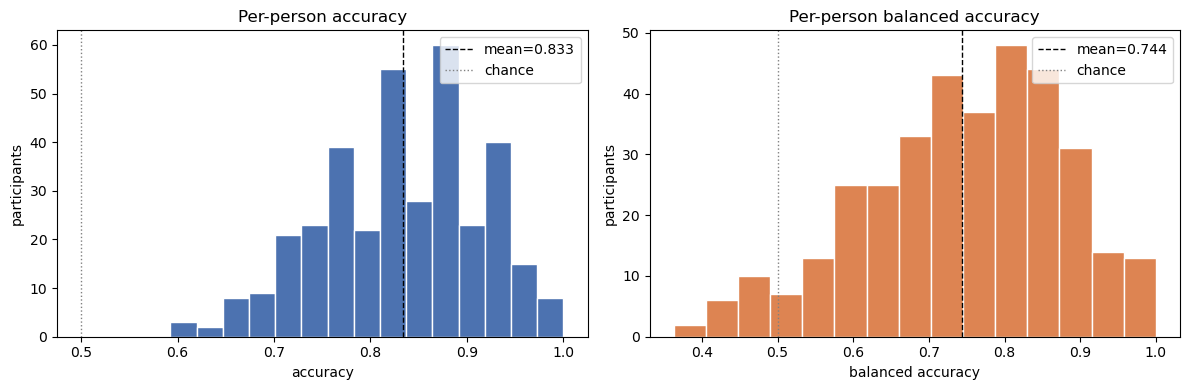

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, color in zip(axes, ["accuracy", "balanced_accuracy"], ["#4C72B0", "#DD8452"]):
    vals = summary_df[col].dropna()
    ax.hist(vals, bins=15, color=color, edgecolor="white")
    ax.axvline(vals.mean(), color="black", ls="--", lw=1, label=f"mean={vals.mean():.3f}")
    ax.axvline(0.5, color="grey", ls=":", lw=1, label="chance")
    ax.set_title(f"Per-person {col.replace('_', ' ')}")
    ax.set_xlabel(col.replace("_", " "))
    ax.set_ylabel("participants")
    ax.legend()
plt.tight_layout()
plt.show()


## Per-person coefficients

Each participant's `coef_summary` comes from a single logistic-regression fit on
all of that participant's trials. The nested `{pid: {model_name: result}}` shape
matches the existing per-participant coefficient/clustering utilities, so those
downstream tools work unchanged.


In [6]:
results_by_pid_nested = {
    pid: {"trial_level_log_reg": res}
    for pid, res in results_by_pid.items()
}


,feature,count,n_pos,n_neg,n_zero,total_occ,prop,sign_varies,majority_sign,minority_count
5,last_before_confirm_question,15,11,4,0,15,0.042135,True,1,4
0,ANSWER_PRESS_NUMBER,35,12,23,0,35,0.098315,True,-1,12
2,area_dwell_proportion__question,44,33,11,0,44,0.123596,True,1,11
6,mean_fixations_count__question,50,13,37,0,50,0.140449,True,-1,13
8,mean_max_fix_pupil_size_z__correct,51,12,39,0,51,0.143258,True,-1,12
10,num_label_visits__correct,53,19,34,0,53,0.148876,True,-1,19
3,has_xyx,56,13,43,0,56,0.157303,True,-1,13
11,skip_rate__correct,66,5,61,0,66,0.185393,True,-1,5
9,num_label_visits__contrast,109,105,4,0,109,0.306180,True,1,4
7,mean_fixations_count__wrong_mean,149,1,148,0,149,0.418539,True,-1,1


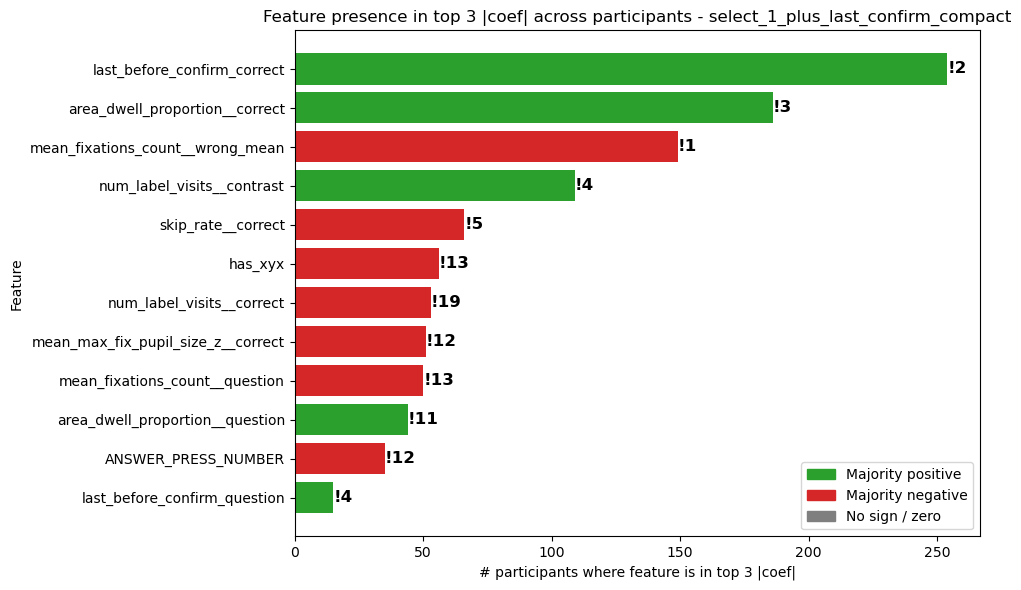

In [7]:
# Small curated set (12 features): show the top-3 |coef| per participant so the
# frequency chart reflects more than a single dominant feature.
TOP_K_WITHIN_PARTICIPANT = 3
TOP_K_FEATURES_TO_SHOW = len(FEATURE_COLS)

fig, freq_df, paths = plot_top_abs_coef_feature_frequency_across_participants(
    results_by_pid=results_by_pid_nested,
    model_name="trial_level_log_reg",
    coef_col="coef",
    top_k_within_participant=TOP_K_WITHIN_PARTICIPANT,
    top_k_features=TOP_K_FEATURES_TO_SHOW,
    title=(
        f"Feature presence in top {TOP_K_WITHIN_PARTICIPANT} |coef| across "
        f"participants - {FEATURE_SET_TAG}"
    ),
    save=False,
    rel_dir="answer_correctness/per_person_loo/feature_presence",
    filename=f"{FEATURE_SET_TAG}_top{TOP_K_WITHIN_PARTICIPANT}_presence",
    paper_dirs=PAPER_DIRS,
    dpi=300,
    close=False,
)
freq_df


,feature,count_participants,mean_rank,median_rank,std_rank,min_rank,max_rank
4,last_before_confirm_correct,356,3.092697,2.0,2.971196,1.0,12.0
1,area_dwell_proportion__correct,356,4.441011,3.0,3.231779,1.0,12.0
7,mean_fixations_count__wrong_mean,356,5.230337,5.0,3.241940,1.0,12.0
9,num_label_visits__contrast,356,5.755618,5.0,3.261270,1.0,12.0
11,skip_rate__correct,356,6.398876,6.0,2.866690,1.0,12.0
3,has_xyx,356,6.915730,7.0,2.966229,1.0,12.0
2,area_dwell_proportion__question,356,7.050562,7.0,2.883215,1.0,12.0
8,mean_max_fix_pupil_size_z__correct,356,7.087079,7.0,3.137372,1.0,12.0
6,mean_fixations_count__question,356,7.117978,7.0,2.898783,1.0,12.0
10,num_label_visits__correct,356,7.162921,8.0,3.028759,1.0,12.0


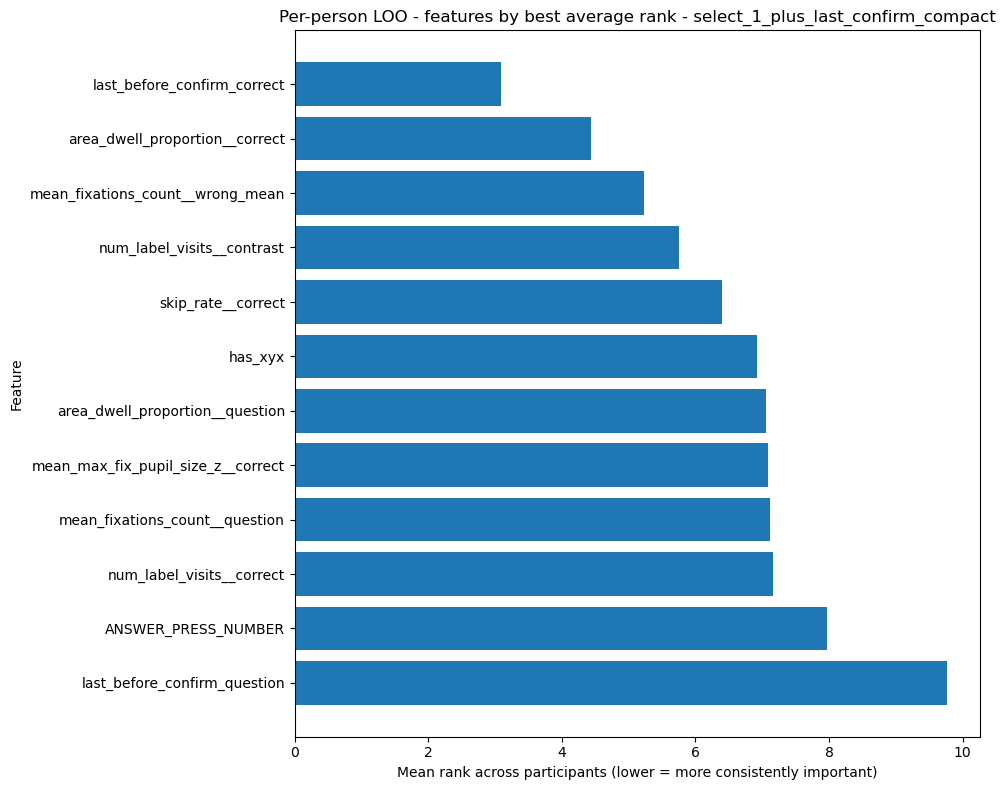

In [8]:
avg_rank_df = compute_feature_avg_rank_across_participants(
    results_by_pid=results_by_pid_nested,
    model_name="trial_level_log_reg",
    coef_col="coef",
    abs_col="abs_coef",
)

fig_rank, df_plot, paths_rank = plot_top_features_by_best_avg_rank(
    avg_rank_df,
    top_k=len(FEATURE_COLS),
    min_participants=1,
    title=f"Per-person LOO - features by best average rank - {FEATURE_SET_TAG}",
    save=False,
    rel_dir="answer_correctness/per_person_loo/avg_rank",
    filename=f"{FEATURE_SET_TAG}_mean_ranks",
    paper_dirs=PAPER_DIRS,
    dpi=300,
    close=False,
)
avg_rank_df


## Mean coefficient across participants

Because the feature set is small and fixed, we can average each feature's
coefficient directly across all participants' full-fit `coef_summary` tables.
The bars are the mean log-odds coefficient; the whiskers span
mean +/- 1 std across participants (a quick read on how stable each effect is
from person to person).


,feature,coef,std,n_participants,abs_coef,ci_low,ci_high
0,last_before_confirm_correct,1.077821,0.622483,356,1.077821,0.455338,1.700303
1,area_dwell_proportion__correct,0.741291,0.577472,356,0.741291,0.163819,1.318762
2,mean_fixations_count__wrong_mean,-0.625621,0.490690,356,0.625621,-1.116310,-0.134931
3,num_label_visits__contrast,0.506184,0.501395,356,0.506184,0.004788,1.007579
4,skip_rate__correct,-0.310889,0.526525,356,0.310889,-0.837414,0.215636
5,area_dwell_proportion__question,0.203558,0.496210,356,0.203558,-0.292652,0.699768
6,mean_max_fix_pupil_size_z__correct,-0.159107,0.549419,356,0.159107,-0.708525,0.390312
7,has_xyx,-0.149721,0.555142,356,0.149721,-0.704863,0.405421
8,mean_fixations_count__question,-0.114944,0.509808,356,0.114944,-0.624752,0.394864
9,last_before_confirm_question,0.106958,0.303609,356,0.106958,-0.196651,0.410567


(<Figure size 900x760 with 1 Axes>,
                                feature      coef       std  n_participants  \
 2     mean_fixations_count__wrong_mean -0.625621  0.490690             356   
 4                   skip_rate__correct -0.310889  0.526525             356   
 6   mean_max_fix_pupil_size_z__correct -0.159107  0.549419             356   
 7                              has_xyx -0.149721  0.555142             356   
 8       mean_fixations_count__question -0.114944  0.509808             356   
 10           num_label_visits__correct -0.064694  0.526500             356   
 11                 ANSWER_PRESS_NUMBER -0.041734  0.476461             356   
 9         last_before_confirm_question  0.106958  0.303609             356   
 5      area_dwell_proportion__question  0.203558  0.496210             356   
 3           num_label_visits__contrast  0.506184  0.501395             356   
 1       area_dwell_proportion__correct  0.741291  0.577472             356   
 0          last

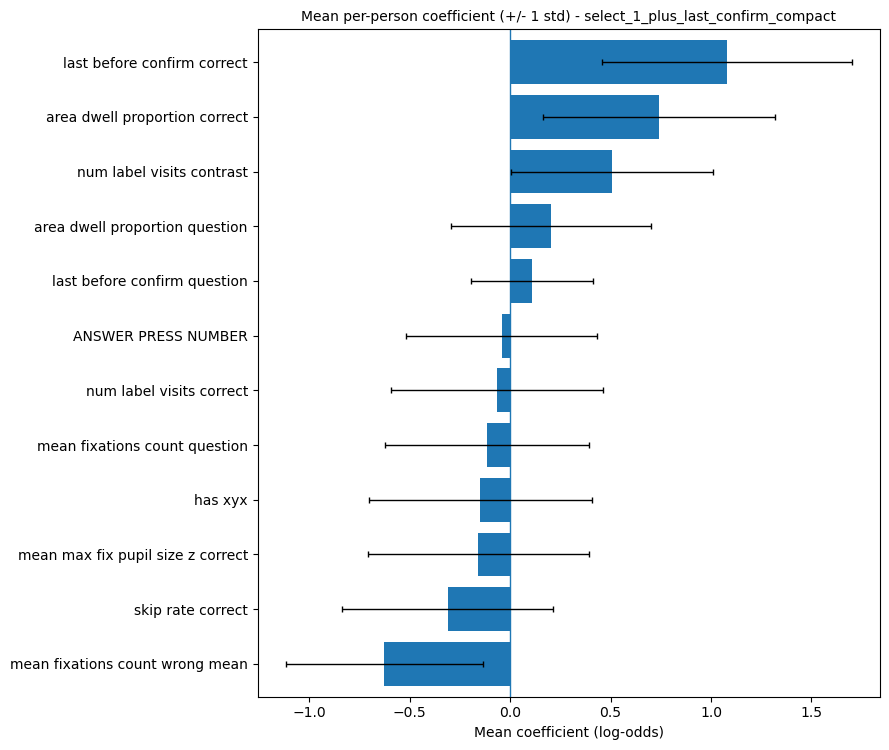

In [9]:
def mean_coef_across_participants(results_by_pid, coef_col="coef"):
    frames = []
    for pid, res in results_by_pid.items():
        cs = getattr(res, "coef_summary", None)
        if cs is None or cs.empty:
            continue
        frames.append(cs[["feature", coef_col]].assign(participant_id=pid))
    long_df = pd.concat(frames, ignore_index=True)
    long_df[coef_col] = pd.to_numeric(long_df[coef_col], errors="coerce")

    agg = (
        long_df.groupby("feature")[coef_col]
        .agg(coef="mean", std="std", n_participants="count")
        .reset_index()
    )
    agg["abs_coef"] = agg["coef"].abs()
    # Show cross-participant spread as +/- 1 std whiskers via the CI columns the
    # bar plotter draws.
    agg["ci_low"] = agg["coef"] - agg["std"]
    agg["ci_high"] = agg["coef"] + agg["std"]
    return agg.sort_values("abs_coef", ascending=False).reset_index(drop=True)


mean_coef_df = mean_coef_across_participants(results_by_pid)
display(mean_coef_df)

plot_coef_summary_barh(
    coef_summary=mean_coef_df,
    value_col="coef",
    top_k=len(FEATURE_COLS),
    significant_only=False,
    title=f"Mean per-person coefficient (+/- 1 std) - {FEATURE_SET_TAG}",
    xlabel="Mean coefficient (log-odds)",
    ylabel="",
    clean_labels=True,
    save=False,
    rel_dir="answer_correctness/per_person_loo/mean_coef",
    filename=f"{FEATURE_SET_TAG}_mean_coef",
    paper_dirs=PAPER_DIRS,
    dpi=300,
    close=False,
)


## What characterizes low-/high-accuracy participants?

Relate each participant's *mean* feature value to how well the per-person model
scores them (`ACC_METRIC`), then contrast the low- vs high-accuracy terciles.

Two guards keep the comparison honest:

- **`MIN_WRONG_TRIALS`** filters out participants with too few wrong
  (minority-class) trials, where balanced accuracy is essentially unestimable and
  collapses toward chance (this also drops the single-class participants that have
  no balanced accuracy at all).
- The analysis is run **twice** - once on **only the features the model was
  trained on** (`FEATURE_COLS`), once on **all available features**
  (`get_full_feature_cols(trial_df)`). Comparing the two separates *"the model
  struggles where its own inputs are weak"* from *"a characteristic sits in
  features the model never sees"* (a potential confound).

Set `ACC_METRIC = "accuracy"` for raw accuracy instead of balanced accuracy.


In [10]:
MIN_WRONG_TRIALS = 8                 # keep participants with >= this many wrong trials
ACC_METRIC = "balanced_accuracy"     # or "accuracy"


def characterize_accuracy(
    summary_df,
    trial_df,
    characterize_cols,
    *,
    acc_metric=ACC_METRIC,
    min_wrong_trials=MIN_WRONG_TRIALS,
    label="",
    top_n_bars=25,
):
    """Relate per-person mean feature values to per-person model accuracy.

    Filters to participants with >= ``min_wrong_trials`` wrong trials (so the
    score is actually estimable), then draws three things and returns the
    intermediate tables:
      1. accuracy vs class-balance scatters,
      2. per-feature Spearman correlation with accuracy,
      3. low- vs high-accuracy (tercile) standardized feature-profile contrast.
    """
    # --- per-person descriptors + minority-class filter ----------------------
    desc = summary_df.copy()
    desc["base_rate_correct"] = desc["n_correct_trials"] / desc["n_trials"]
    desc["minority_rate"] = (
        desc[["n_correct_trials", "n_wrong_trials"]].min(axis=1) / desc["n_trials"]
    )
    n_before = len(desc)
    desc = desc[desc["n_wrong_trials"] >= min_wrong_trials].copy()
    print(
        f"[{label}] {len(desc)}/{n_before} participants kept "
        f"(n_wrong_trials >= {min_wrong_trials}); characterizing '{acc_metric}' "
        f"over {len(characterize_cols)} features"
    )

    # --- per-participant mean of each feature --------------------------------
    feat_numeric = trial_df[list(characterize_cols)].apply(pd.to_numeric, errors="coerce")
    part_feat_means = (
        feat_numeric.groupby(trial_df[Con.PARTICIPANT_ID]).mean().reset_index()
    )
    merged = desc.merge(part_feat_means, on=Con.PARTICIPANT_ID, how="inner")

    # --- 1) accuracy vs class balance ----------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    for ax, xcol in zip(axes, ["base_rate_correct", "minority_rate"]):
        ax.scatter(merged[xcol], merged[acc_metric], alpha=0.6, color="#4C72B0")
        ax.axhline(0.5, color="grey", ls=":", lw=1, label="chance")
        ax.set_xlabel(xcol.replace("_", " "))
        ax.set_ylabel(acc_metric.replace("_", " "))
        ax.set_title(f"{acc_metric.replace('_', ' ')} vs {xcol.replace('_', ' ')}")
        ax.legend()
    fig.suptitle(f"[{label}] accuracy vs class balance", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

    # --- 2) per-feature correlation with accuracy ----------------------------
    feat_corr = (
        pd.DataFrame({
            "feature": list(characterize_cols),
            "spearman_r": [
                merged[[acc_metric, f]].dropna().corr(method="spearman").iloc[0, 1]
                for f in characterize_cols
            ],
        })
        .assign(abs_r=lambda d: d["spearman_r"].abs())
        .sort_values("abs_r", ascending=False)
        .reset_index(drop=True)
    )
    _top = feat_corr.dropna(subset=["spearman_r"]).head(top_n_bars).sort_values("spearman_r")
    fig, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(_top) + 1)))
    ax.barh(
        _top["feature"], _top["spearman_r"],
        color=["#DD8452" if v < 0 else "#4C72B0" for v in _top["spearman_r"]],
    )
    ax.axvline(0, color="black", lw=1)
    ax.set_xlabel(f"Spearman corr of per-person mean with {acc_metric.replace('_', ' ')}")
    ax.set_title(f"[{label}] feature levels vs model performance (top {len(_top)})")
    plt.tight_layout()
    plt.show()

    # --- 3) low- vs high-accuracy group profile ------------------------------
    q_low, q_high = merged[acc_metric].quantile([1 / 3, 2 / 3])
    low = merged[merged[acc_metric] <= q_low]
    high = merged[merged[acc_metric] >= q_high]
    print(
        f"[{label}] low: {len(low)} ({acc_metric} <= {q_low:.3f})  |  "
        f"high: {len(high)} ({acc_metric} >= {q_high:.3f})"
    )
    for col in ["base_rate_correct", "minority_rate", "n_trials"]:
        print(f"    {col:18s}: low={low[col].mean():.3f}  high={high[col].mean():.3f}")

    cols = list(characterize_cols)
    stds = merged[cols].std(ddof=0).replace(0, 1.0)
    z = (merged[cols] - merged[cols].mean()) / stds
    group_cmp = (
        pd.DataFrame({
            "low_acc_mean_z": z.loc[low.index].mean(),
            "high_acc_mean_z": z.loc[high.index].mean(),
        })
        .assign(diff=lambda d: d["low_acc_mean_z"] - d["high_acc_mean_z"])
        .sort_values("diff", key=lambda s: s.abs(), ascending=False)
    )
    _d = group_cmp.dropna(subset=["diff"]).head(top_n_bars).sort_values("diff")
    fig, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(_d) + 1)))
    ax.barh(
        _d.index, _d["diff"],
        color=["#DD8452" if v < 0 else "#4C72B0" for v in _d["diff"]],
    )
    ax.axvline(0, color="black", lw=1)
    ax.set_xlabel("standardized mean difference: low-acc minus high-acc")
    ax.set_title(f"[{label}] feature profile: low- vs high-accuracy (top {len(_d)})")
    plt.tight_layout()
    plt.show()

    return {"merged": merged, "feat_corr": feat_corr, "group_cmp": group_cmp}


### Graph set 1 - features the model trained on

Only the 12 `FEATURE_COLS`. This tells you *where the model's own inputs carry
(or lack) per-person signal*.


[trained features] 197/356 participants kept (n_wrong_trials >= 8); characterizing 'balanced_accuracy' over 12 features


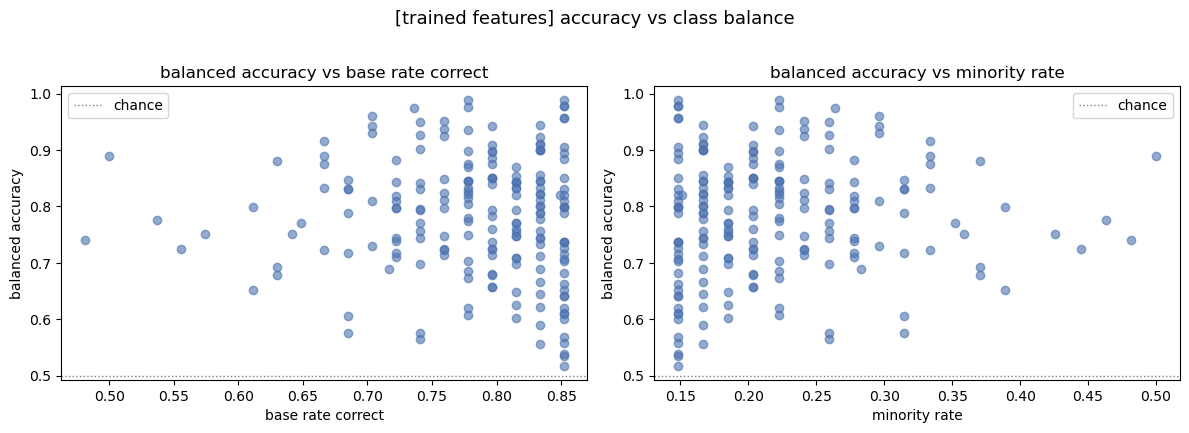

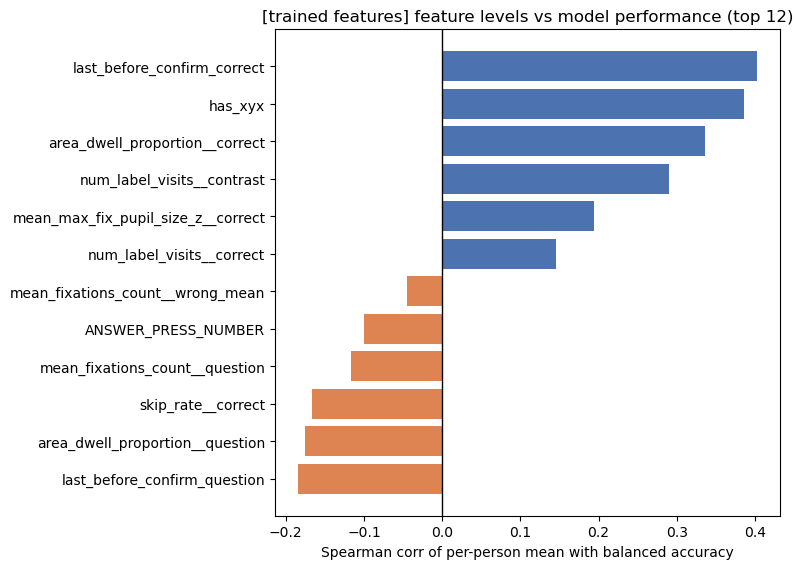

[trained features] low: 66 (balanced_accuracy <= 0.737)  |  high: 66 (balanced_accuracy >= 0.833)
    base_rate_correct : low=0.791  high=0.779
    minority_rate     : low=0.209  high=0.221
    n_trials          : low=53.985  high=53.985


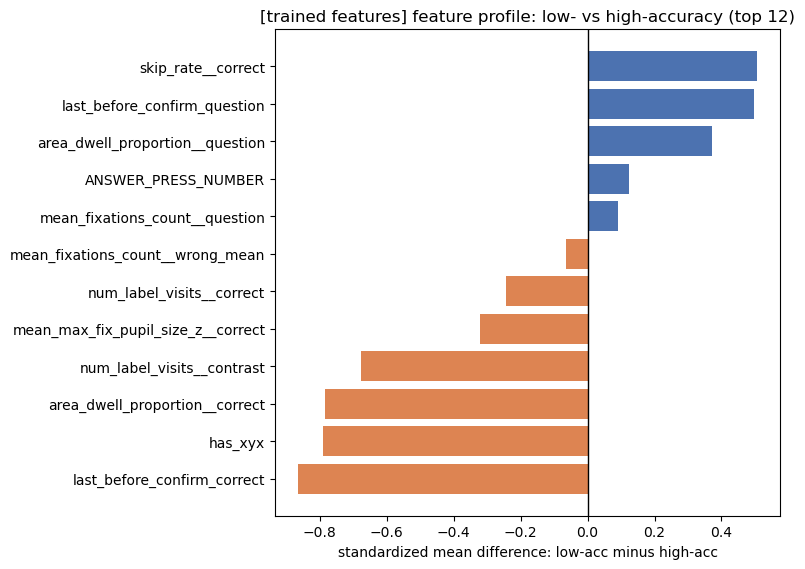

,feature,spearman_r,abs_r
0,last_before_confirm_correct,0.402427,0.402427
1,has_xyx,0.386316,0.386316
2,area_dwell_proportion__correct,0.336400,0.336400
3,num_label_visits__contrast,0.290277,0.290277
4,mean_max_fix_pupil_size_z__correct,0.194386,0.194386
5,last_before_confirm_question,-0.184290,0.184290
6,area_dwell_proportion__question,-0.175244,0.175244
7,skip_rate__correct,-0.166485,0.166485
8,num_label_visits__correct,0.145095,0.145095
9,mean_fixations_count__question,-0.116966,0.116966


In [11]:
trained_out = characterize_accuracy(
    summary_df,
    trial_df,
    characterize_cols=FEATURE_COLS,
    label="trained features",
)
display(trained_out["feat_corr"])


### Graph set 2 - all available features

Every feature in the table, including many the model never sees. Anything that
separates low- from high-accuracy participants **here but not above** is a
characteristic outside the model's inputs - a candidate confound worth a look.


[all features] 197/356 participants kept (n_wrong_trials >= 8); characterizing 'balanced_accuracy' over 98 features


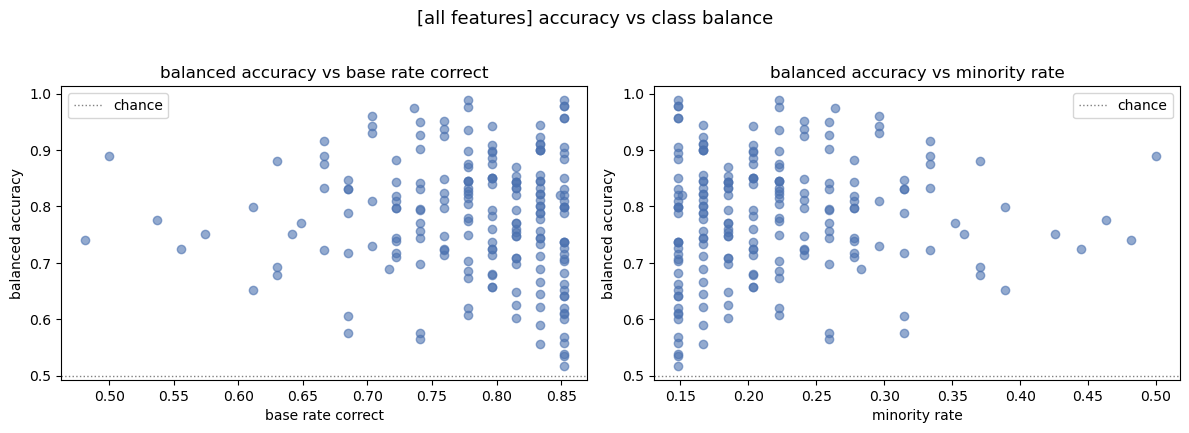

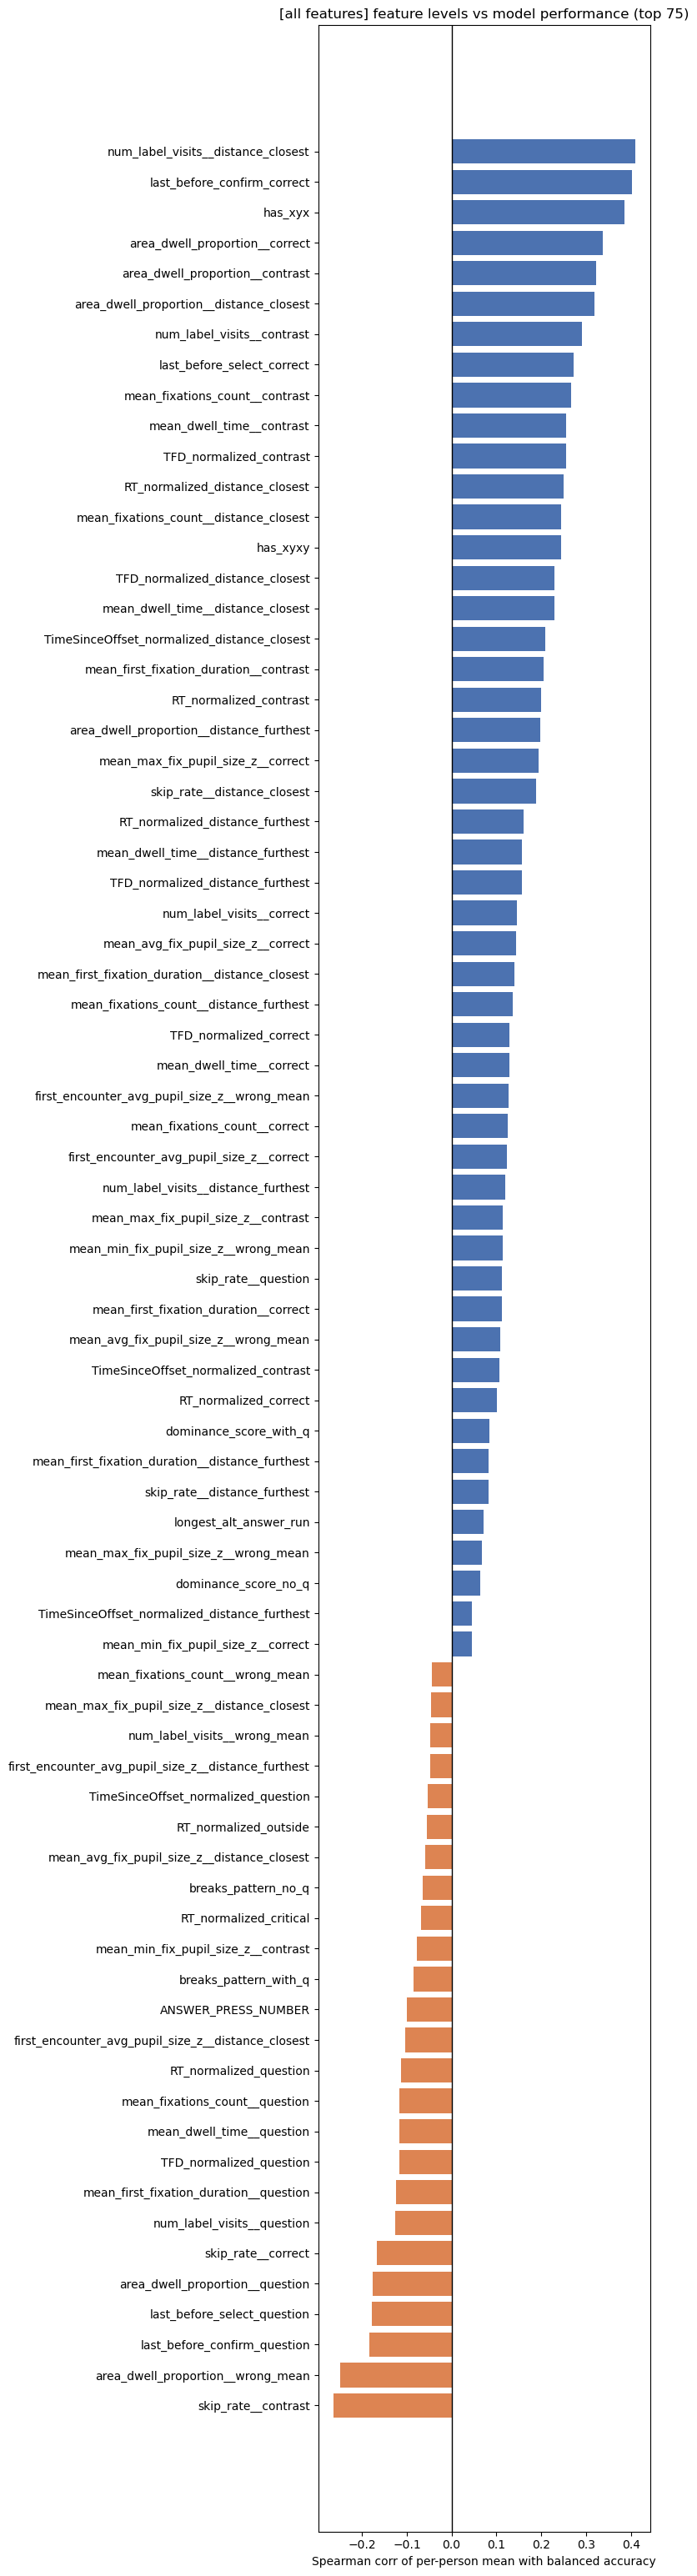

[all features] low: 66 (balanced_accuracy <= 0.737)  |  high: 66 (balanced_accuracy >= 0.833)
    base_rate_correct : low=0.791  high=0.779
    minority_rate     : low=0.209  high=0.221
    n_trials          : low=53.985  high=53.985


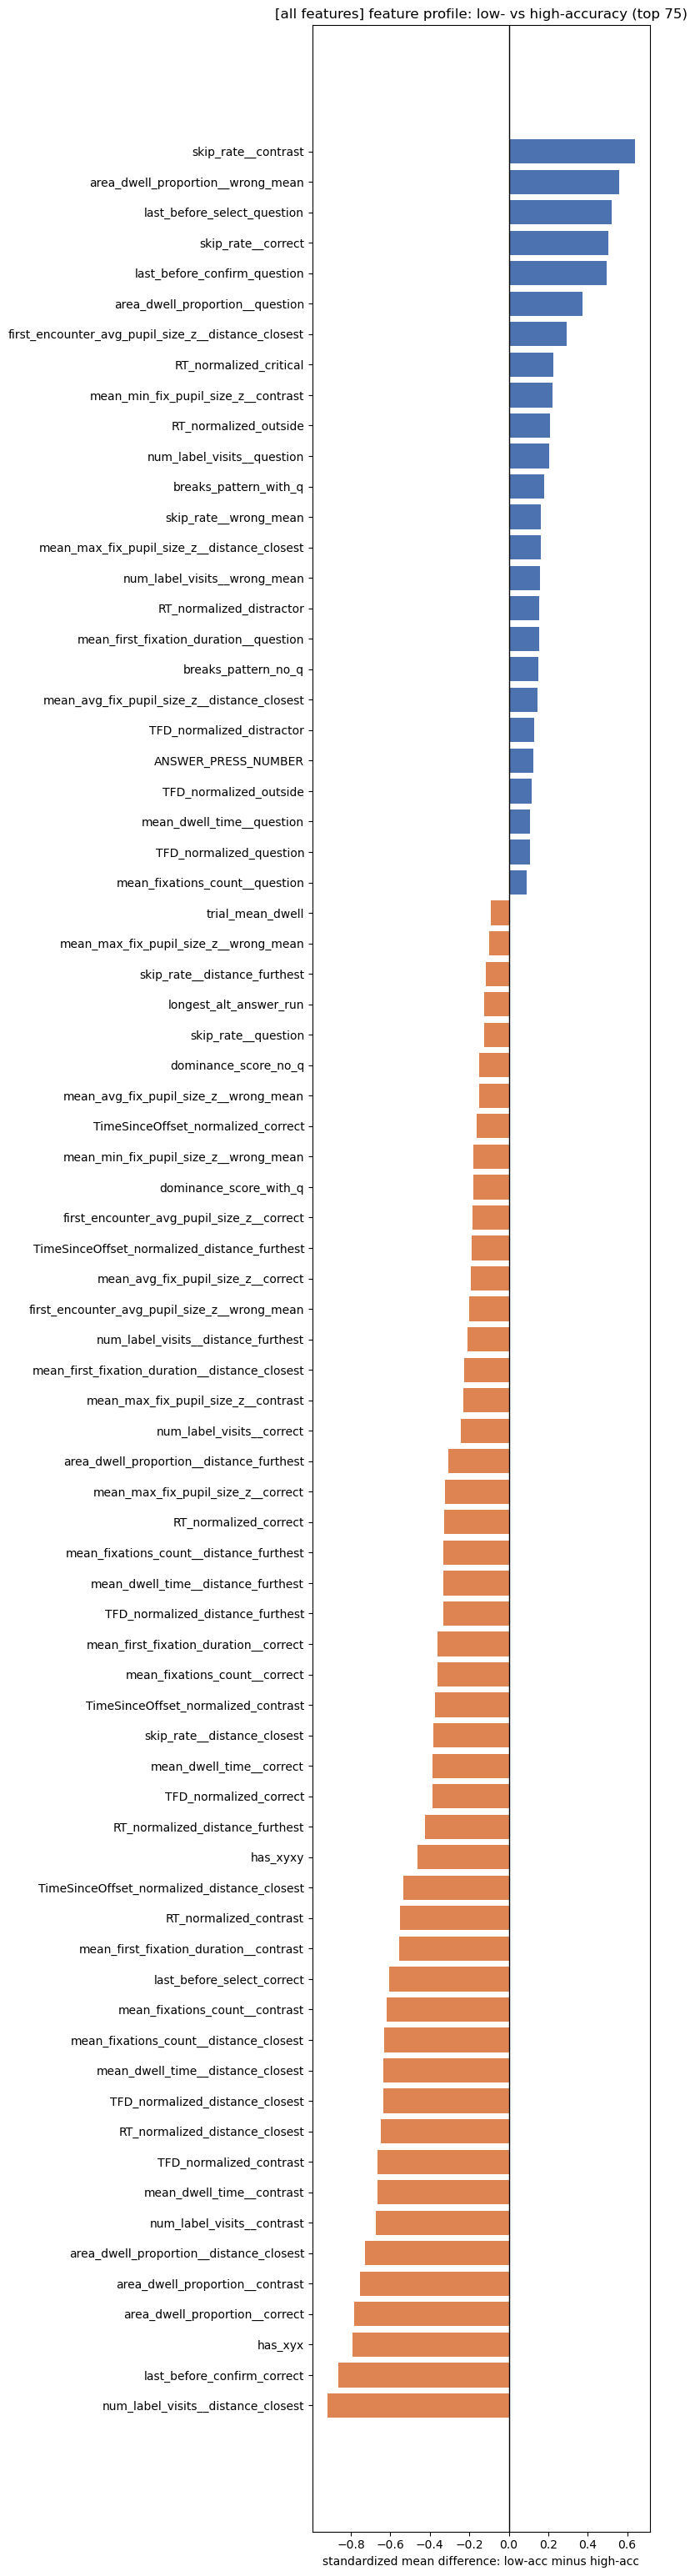

,feature,spearman_r,abs_r
0,num_label_visits__distance_closest,0.409503,0.409503
1,last_before_confirm_correct,0.402427,0.402427
2,has_xyx,0.386316,0.386316
3,area_dwell_proportion__correct,0.336400,0.336400
4,area_dwell_proportion__contrast,0.322700,0.322700
5,area_dwell_proportion__distance_closest,0.318081,0.318081
6,num_label_visits__contrast,0.290277,0.290277
7,last_before_select_correct,0.272178,0.272178
8,mean_fixations_count__contrast,0.266795,0.266795
9,skip_rate__contrast,-0.263961,0.263961


In [12]:
ALL_FEATURE_COLS = FG.ALL_FEATURES

all_out = characterize_accuracy(
    summary_df,
    trial_df,
    characterize_cols=ALL_FEATURE_COLS,
    label="all features",
    top_n_bars=75
)
display(all_out["feat_corr"].head(30))


Graph 1

Positive bar (blue): people who do more of this behavior are people the model predicts better. This trait marks a model-friendly participant.
Negative bar (orange): people who do more of this are people the model predicts worse. This trait marks a model-hostile participant.

has_xyx (+0.27) — back-and-forth comparison between options. The single clearest marker: people who actively compare answers are the ones the model reads most reliably.

skip_rate__correct at −0.17 -- Participants who skim the correct answer — leave a larger share of its words unread — tend to be predicted worse (lower balanced accuracy). People whose average correct-answer skip rate is high are people the model predicts worse (lower balanced accuracy).

Graph 2
Blue (positive): trait is elevated in the people the model does worst on → the model-hostile signature.
Orange (negative): trait is elevated in the people the model does best on → the model-friendly signature.